# Personality Prediction: Introvert vs Extrovert

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, RocCurveDisplay)

sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42

In [3]:
df = pd.read_csv("E:\\Intern\\personality_api_package\\personality_dataset.csv")
print('Shape:', df.shape)
df.head()

Shape: (2900, 8)


,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [ ]:
print(df.info())

In [4]:
df.dtypes

Time_spent_Alone             float64
Stage_fear                    object
Social_event_attendance      float64
Going_outside                float64
Drained_after_socializing     object
Friends_circle_size          float64
Post_frequency               float64
Personality                   object
dtype: object

In [5]:
df.isnull().sum().rename('missing').to_frame()

,missing
Time_spent_Alone,63
Stage_fear,73
Social_event_attendance,62
Going_outside,66
Drained_after_socializing,52
Friends_circle_size,77
Post_frequency,65
Personality,0


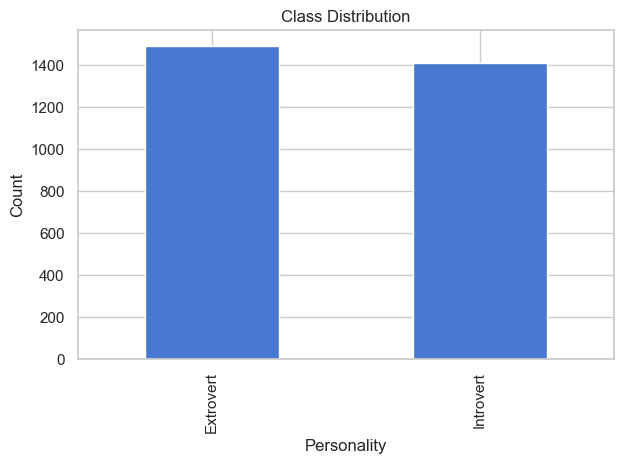

In [6]:
df['Personality'].value_counts().plot(kind='bar', title='Class Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

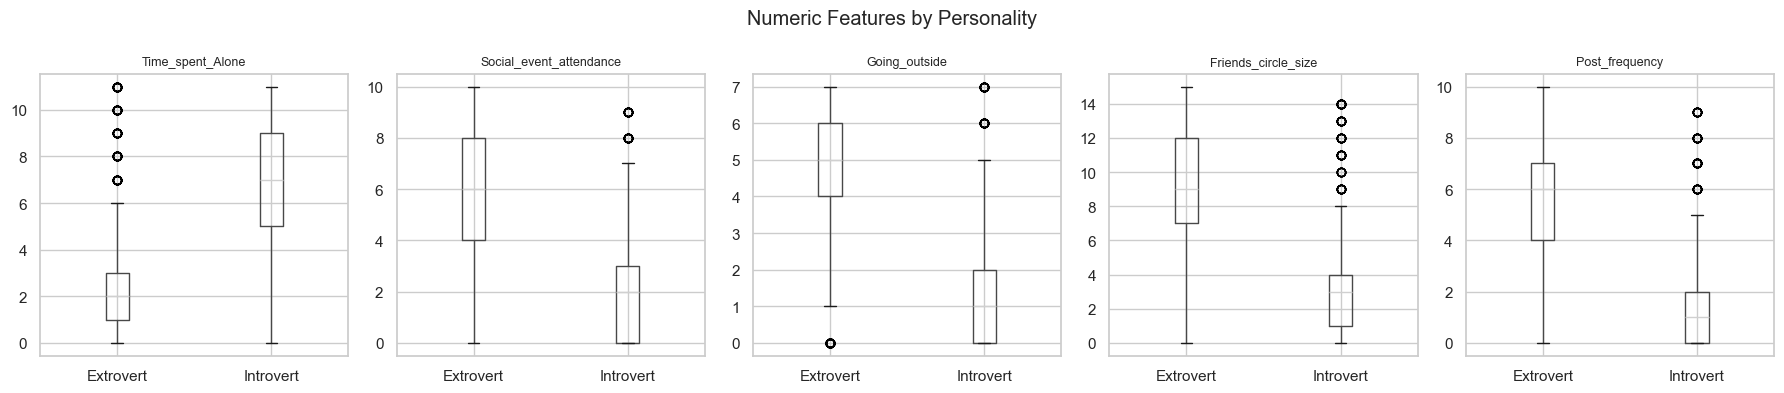

In [7]:
num_cols = ['Time_spent_Alone', 'Social_event_attendance',
            'Going_outside', 'Friends_circle_size', 'Post_frequency']
cat_cols = ['Stage_fear', 'Drained_after_socializing']

# Numeric distributions by personality
fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    df.boxplot(column=col, by='Personality', ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
plt.suptitle('Numeric Features by Personality')
plt.tight_layout()
plt.show()

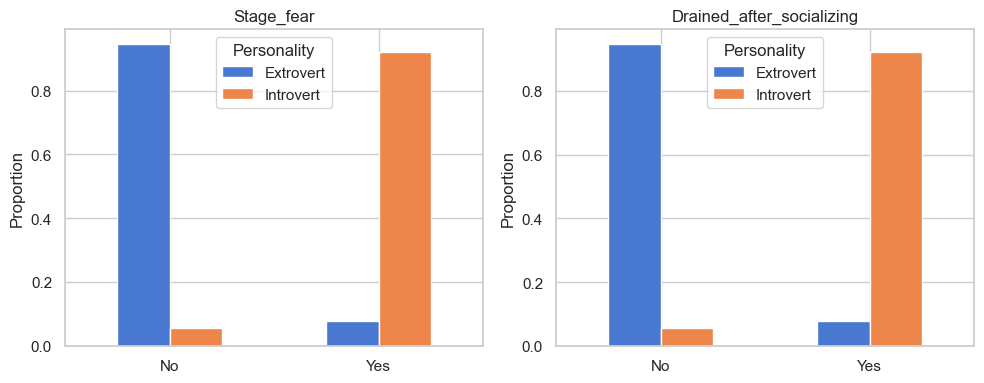

In [8]:
# Categorical features
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, cat_cols):
    ct = pd.crosstab(df[col], df['Personality'], normalize='index')
    ct.plot(kind='bar', ax=ax, title=col)
    ax.set_ylabel('Proportion')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

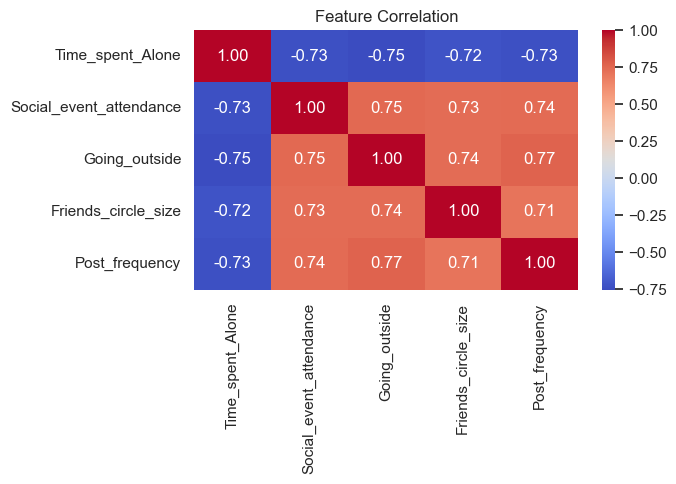

In [9]:
# Correlation heatmap (numeric only)
corr = df[num_cols].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.tight_layout()
plt.show()

In [11]:
X = df.drop('Personality', axis=1)
# Encode target: 1 = Introvert, 0 = Extrovert
y = (df['Personality'] == 'Introvert').astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print(f'Train: {len(X_train)}  |  Test: {len(X_test)}')

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols),
])

Train: 2320  |  Test: 580


In [12]:
candidates = {
    'Logistic Regression':  LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest':        RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'Gradient Boosting':    GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = {}

for name, clf in candidates.items():
    pipe = Pipeline([('prep', preprocessor), ('clf', clf)])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f'{name:28s}  {scores.mean():.4f} ± {scores.std():.4f}')

Logistic Regression           0.9332 ± 0.0084
Random Forest                 0.9280 ± 0.0044
Gradient Boosting             0.9379 ± 0.0091


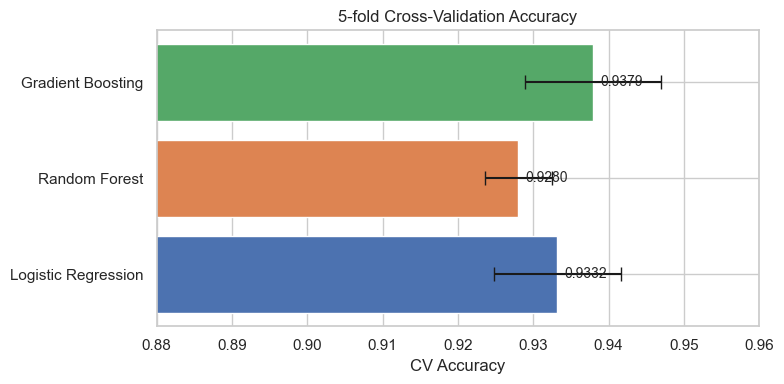

In [13]:
# Plot CV results
means = {k: v.mean() for k, v in results.items()}
stds  = {k: v.std()  for k, v in results.items()}
names = list(means.keys())

plt.figure(figsize=(8, 4))
bars = plt.barh(names, [means[n] for n in names], xerr=[stds[n] for n in names],
                capsize=5, color=['#4C72B0','#DD8452','#55A868'])
plt.xlabel('CV Accuracy')
plt.title('5-fold Cross-Validation Accuracy')
plt.xlim(0.88, 0.96)
for bar, name in zip(bars, names):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{means[name]:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

**Winner: Gradient Boosting** — highest mean CV accuracy (≈ 93.8 %).

In [14]:
best_clf = GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE)
final_pipe = Pipeline([('prep', preprocessor), ('clf', best_clf)])
final_pipe.fit(X_train, y_train)

y_pred  = final_pipe.predict(X_test)
y_proba = final_pipe.predict_proba(X_test)[:, 1]

print(f'Test Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC       : {roc_auc_score(y_test, y_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Extrovert', 'Introvert']))

Test Accuracy : 0.9172
ROC-AUC       : 0.9559

              precision    recall  f1-score   support

   Extrovert       0.94      0.90      0.92       298
   Introvert       0.90      0.94      0.92       282

    accuracy                           0.92       580
   macro avg       0.92      0.92      0.92       580
weighted avg       0.92      0.92      0.92       580



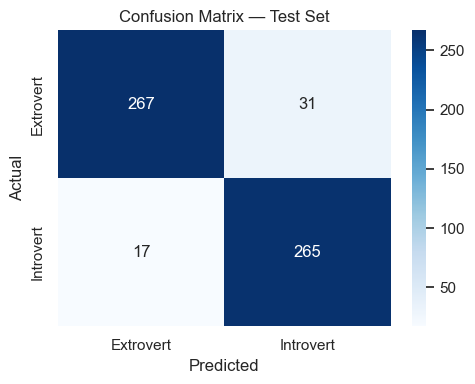

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Extrovert', 'Introvert'],
            yticklabels=['Extrovert', 'Introvert'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

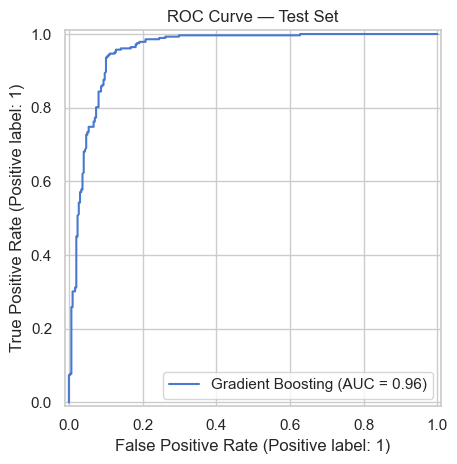

In [17]:
# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba,
                                  name='Gradient Boosting')
plt.title('ROC Curve — Test Set')
plt.tight_layout()
plt.show()

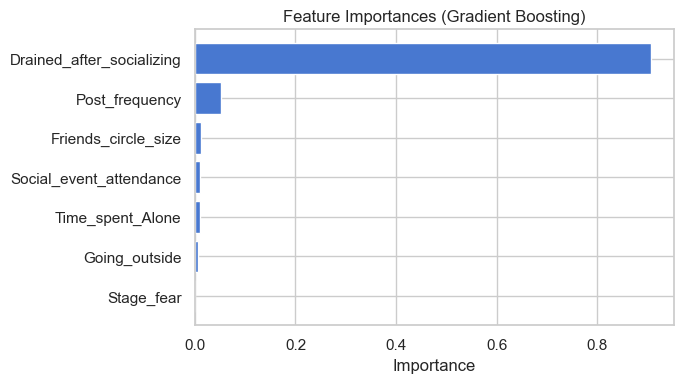

                  feature  importance
Drained_after_socializing    0.906843
           Post_frequency    0.052195
      Friends_circle_size    0.012231
  Social_event_attendance    0.010800
         Time_spent_Alone    0.010608
            Going_outside    0.007171
               Stage_fear    0.000153


In [18]:
# Feature importances
feat_names = num_cols + cat_cols
imp = best_clf.feature_importances_
imp_df = pd.DataFrame({'feature': feat_names, 'importance': imp})\
           .sort_values('importance', ascending=True)

plt.figure(figsize=(7, 4))
plt.barh(imp_df['feature'], imp_df['importance'])
plt.xlabel('Importance')
plt.title('Feature Importances (Gradient Boosting)')
plt.tight_layout()
plt.show()

print(imp_df.sort_values('importance', ascending=False).to_string(index=False))

In [19]:
joblib.dump(final_pipe, 'personality_model.pkl')
print('Model saved → personality_model.pkl')

Model saved → personality_model.pkl


In [21]:
# Local sanity check (no HTTP needed)
sample = pd.DataFrame([{
    'Time_spent_Alone': 8, 'Stage_fear': 'Yes',
    'Social_event_attendance': 2, 'Going_outside': 1,
    'Drained_after_socializing': 'Yes', 'Friends_circle_size': 3,
    'Post_frequency': 1
}])
pred  = final_pipe.predict(sample)[0]
proba = final_pipe.predict_proba(sample)[0]
label = 'Introvert' if pred == 1 else 'Extrovert'
print(f'Prediction: {label}  (confidence={proba[pred]:.4f})')

Prediction: Introvert  (confidence=0.8400)


## Summary

| Metric | Value |
|---|---|
| Algorithm | Gradient Boosting (200 trees) |
| CV Accuracy (5-fold) | 93.8 % |
| Test Accuracy | 91.7 % |
| Test ROC-AUC | 95.6 % |
| Dominant feature | `Drained_after_socializing` (90.7 % importance) |

**Assumptions made:**
- Missing values (<3 % per column) imputed with median/mode — a safe choice given low missingness and no obvious MNAR pattern.
- `Yes`/`No` binary fields are ordinally encoded (0/1); this is equivalent to one-hot encoding for two-class variables.
- No additional hyperparameter tuning was performed beyond choosing n_estimators=200; the CV score showed little variance, indicating the default settings are already robust.